Index(['NO.', 'Time', 'ms', 'A', 'V', 'A1234567890', 'AO1234'], dtype='object')

Missing values per column:
NO.             0
Time            0
ms              0
A               0
V               0
A1234567890     0
AO1234          0
milliseconds    0
TimePlot        0
dtype: int64

Total energy consumed: 0.010051285977777758 kWh

Efficiency: 139.29 km/kWh


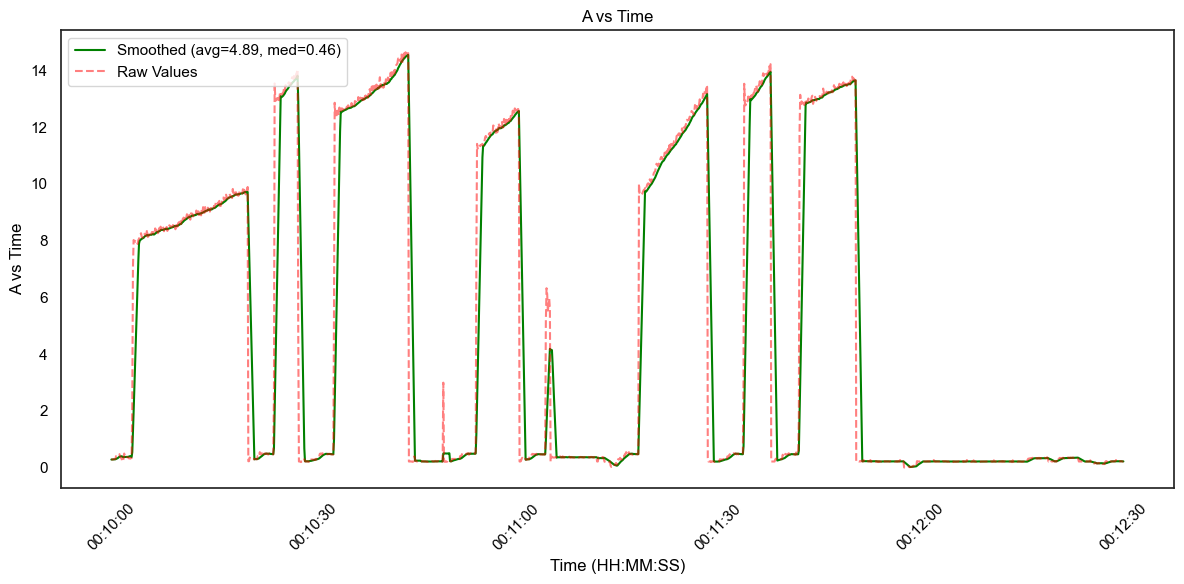

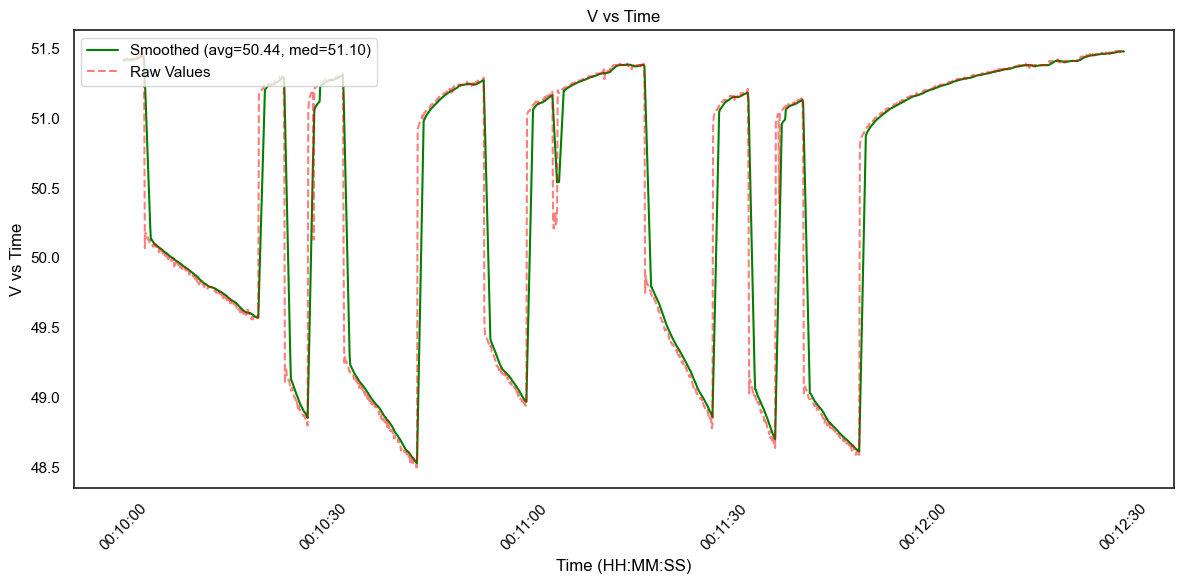

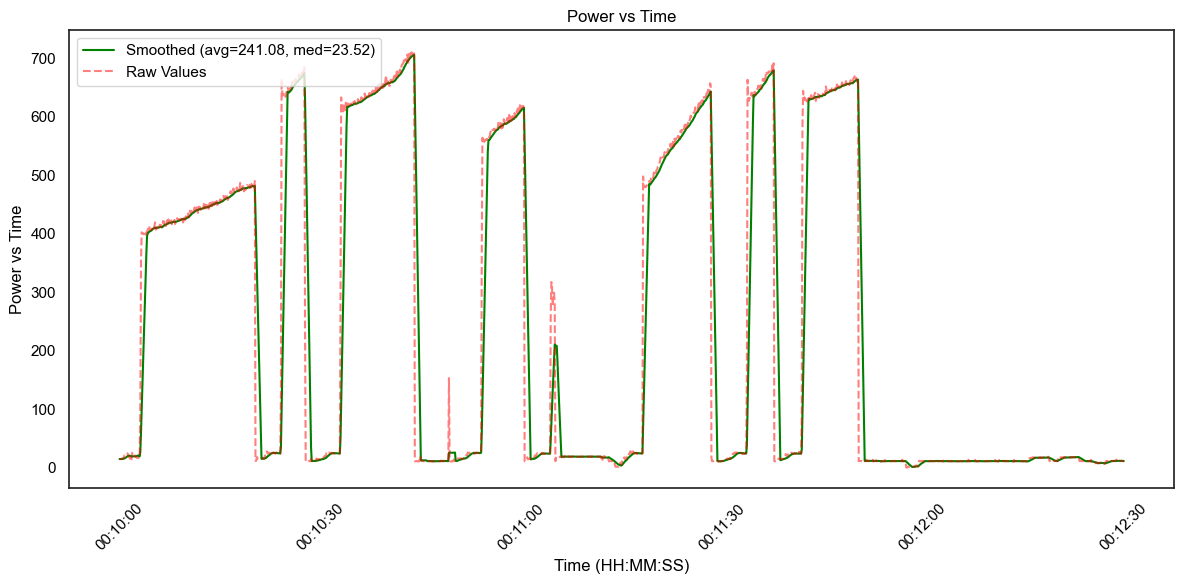

In [78]:
#Datalogger
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd4

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
import matplotlib.dates as mdates
import os
import re
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import zscore

sns.set(style='white')  # light background
date = "250817"
time = "122827"
data_folder = './data'
# data_folder = f'./{date}/'
# file = f'{date}-{time}.csv'
file = f'TEST2_CP12.CSV'
path = os.path.join(data_folder, file)
delimiter = ','
skiprows = 23
distance = 1.4 #Distance in km, used for efficiency calculation
Ticks = False  # Set to False if did not correct ticks
start_throttle = 0  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers

start_ms = 600000
test_duration = 150000


# Load and clean data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
#data = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
#data['Tick'] = (data['Tick'].apply(clean_cell))
# data = pd.read_csv(path, delimiter = delimiter, skiprows = skiprows)
# data.columns = data.columns.str.strip()
data = pd.read_csv(path, delimiter=',', skiprows=22)
data.columns = data.columns.str.strip()

print(data.columns)

# Remove rows before the first throttle > start_throttle
if throttle_start_flag:
    start_throttle_index = data[data['Throttle'] >= start_throttle].index.min()
    data = data.iloc[start_throttle_index:]

# Convert Tick to time
if Ticks:
    data['Tick'] = data['Tick'].astype(int)  # Ensure Tick is int
    data['Time'] = pd.to_timedelta(data['Tick'], unit='ms')
    #Datalogger
    # import numpy as np
    # import matplotlib.pyplot as plt
    # import pandas as pd4

    import matplotlib.pyplot as plt
    import matplotlib.dates as mdates

    sns.set(style='white')  # light background
    date = "250817"
    time = "122827"
    data_folder = './data'
    # data_folder = f'./{date}/'
    # file = f'{date}-{time}.csv'
    file = f'TEST2_CP12.CSV'
    path = os.path.join(data_folder, file)
    delimiter = ','
    skiprows = 23
    distance = 1.4 #Distance in km, used for efficiency calculation
    Ticks = False  # Set to False if did not correct ticks
    start_throttle = 0  # Minimum throttle to start plotting
    throttle_start_flag = False
    plot_outliers = False  # Set to False to not plot outliers

    start_ms = 600000
    test_duration = 1


    # Load and clean data
    # def clean_cell(cell):
    #     # Keep only alphanumeric and spaces
    #     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
    # def last_digits(cell, n=5):
    #     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
    #     return match.group(1) if match else ''
    #data = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
    #data['Tick'] = (data['Tick'].apply(clean_cell))
    # data = pd.read_csv(path, delimiter = delimiter, skiprows = skiprows)
    # data.columns = data.columns.str.strip()
    data = pd.read_csv(path, delimiter=',', skiprows=22)
    data.columns = data.columns.str.strip()

    print(data.columns)

    # Remove rows before the first throttle > start_throttle
    if throttle_start_flag:
        start_throttle_index = data[data['Throttle'] >= start_throttle].index.min()
        data = data.iloc[start_throttle_index:]

    # Convert Tick to time
    if Ticks:
        data['Tick'] = data['Tick'].astype(int)  # Ensure Tick is int
        data['Time'] = pd.to_timedelta(data['Tick'], unit='ms')
        data['TimePlot'] = pd.Timestamp("2026-04-04") + data['Time']
    # else:
        # data['TimePlot'] = range(len(data))

    # Convert NO to milliseconds
    if 'NO.' in data.columns:
        data['milliseconds'] = data['NO.'] * 100

    #Convert milliseconds to time
    if 'milliseconds' in data.columns:
        data['Time'] = pd.to_timedelta(data['milliseconds'], unit='ms')
        data['TimePlot'] = pd.Timestamp("2026-04-04") + data['Time']
    # Truncate data 
    if start_ms != 0:
        start_time = pd.Timestamp("2026-04-04") + pd.to_timedelta(start_ms, unit='ms')
        end_time = start_time + pd.to_timedelta(test_duration, unit='ms')
        data = data[(data['TimePlot'] >= start_time) & (data['TimePlot'] <= end_time)]
    # Check for missing values
    print("\nMissing values per column:")
    print(data.isnull().sum())

    #Convert to actual numbers
    data['A'] = data['A'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
    # data['V'] = data['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
    # data['mA'] = data['mA'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
    data['V'] = data['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
    #Add power calculation
    if 'A' in data.columns and 'V' in data.columns:
        # data['A'] = data['mA'] / 1000  # convert mA → A
        data['Power'] = (data['A']) * (data['V'])

    #Add total energy calculation
    if 'Power' in data.columns:
        energy_joules = np.trapezoid(data['Power'], x = data['milliseconds'] / 1e3)
        energy_kWh = energy_joules / 3600000  # Convert from J to kWh
        print(f"\nTotal energy consumed: {energy_kWh} kWh")

    if distance !=1:
        #Calculate efficiency
        efficiency = distance/energy_kWh  # kWh per meter
        print(f"\nEfficiency: {efficiency:.2f} km/kWh")



    # Columns to visualize
    #columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
    columns_to_plot = ['A','V','Power']
    #data.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

    # Plot each column
    for col in columns_to_plot:
        if col in data.columns:
            x = data['TimePlot']
            y = data[col]
            y_smooth = y.rolling(window=10, min_periods = 1).mean()

            # Stats
            avg = y.mean()
            med = y.median()

            # Outliers (Z-score method)
            z_scores = zscore(y)
            outliers = np.abs(z_scores) > 2

            # Start plotting
            fig, ax = plt.subplots(figsize=(12, 6))

            #Use numpy arrays for plotting with only first dimension (this is weird)
        

            # Smoothed line
            ax.plot(x, y_smooth, color='green', label=f'Smoothed (avg={avg:.2f}, med={med:.2f})')

            # Raw dashed line
            ax.plot(x,y, linestyle='--', color='red', alpha=0.5, label='Raw Values')

            # Outliers as blue dots
            if plot_outliers:
                ax.scatter(x[outliers], y[outliers], color='blue', label='Outliers')

            # Labeling and formatting
            ax.set_xlabel("Time (HH:MM:SS)", color='black')
            ax.set_ylabel(f"{col} vs Time", color='black')
            ax.set_title(f"{col} vs Time", color='black')
            ax.tick_params(axis='x', colors='black', rotation=45)
            ax.tick_params(axis='y', colors='black')

            ax.xaxis.set_major_locator(mdates.AutoDateLocator())
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

            # Legend in black
            legend = ax.legend(loc='upper left')
            for text in legend.get_texts():
                text.set_color('black')

            plt.tight_layout()
            plt.show()
        else:
            print(f"Column '{col}' not found in dataset.")

# else:
    # data['TimePlot'] = range(len(data))

# Convert NO to milliseconds
if 'NO.' in data.columns:
    data['milliseconds'] = data['NO.'] * 100

#Convert milliseconds to time
if 'milliseconds' in data.columns:
    data['Time'] = pd.to_timedelta(data['milliseconds'], unit='ms')
    data['TimePlot'] = pd.Timestamp("2026-04-04") + data['Time']
# Truncate data 
if start_ms != 0:
    start_time = pd.Timestamp("2026-04-04") + pd.to_timedelta(start_ms, unit='ms')
    end_time = start_time + pd.to_timedelta(test_duration, unit='ms')
    data = data[(data['TimePlot'] >= start_time) & (data['TimePlot'] <= end_time)]
# Check for missing values
print("\nMissing values per column:")
print(data.isnull().sum())

#Convert to actual numbers
data['A'] = data['A'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
# data['V'] = data['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
# data['mA'] = data['mA'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
data['V'] = data['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
#Add power calculation
if 'A' in data.columns and 'V' in data.columns:
    # data['A'] = data['mA'] / 1000  # convert mA → A
    data['Power'] = (data['A']) * (data['V'])

#Add total energy calculation
if 'Power' in data.columns:
    energy_joules = np.trapezoid(data['Power'], x = data['milliseconds'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_kWh} kWh")

if distance !=1:
    #Calculate efficiency
    efficiency = distance/energy_kWh  # kWh per meter
    print(f"\nEfficiency: {efficiency:.2f} km/kWh")



# Columns to visualize
#columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
columns_to_plot = ['A','V','Power']
#data.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data.columns:
        x = data['TimePlot']
        y = data[col]
        y_smooth = y.rolling(window=10, min_periods = 1).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y)
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize=(12, 6))

        #Use numpy arrays for plotting with only first dimension (this is weird)
    

        # Smoothed line
        ax.plot(x, y_smooth, color='green', label=f'Smoothed (avg={avg:.2f}, med={med:.2f})')

        # Raw dashed line
        ax.plot(x,y, linestyle='--', color='red', alpha=0.5, label='Raw Values')

        # Outliers as blue dots
        if plot_outliers:
            ax.scatter(x[outliers], y[outliers], color='blue', label='Outliers')

        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis='x', colors='black', rotation=45)
        ax.tick_params(axis='y', colors='black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")



Missing values per column:
NO.             0
Time            0
ms              0
A               0
V               0
C               0
A1234567890     0
ALP1-4          0
AO1234          0
TimePlot        0
milliseconds    0
dtype: int64

Total energy consumed: 0.03492905695222222 kWh

Efficiency: 68.71 km/kWh


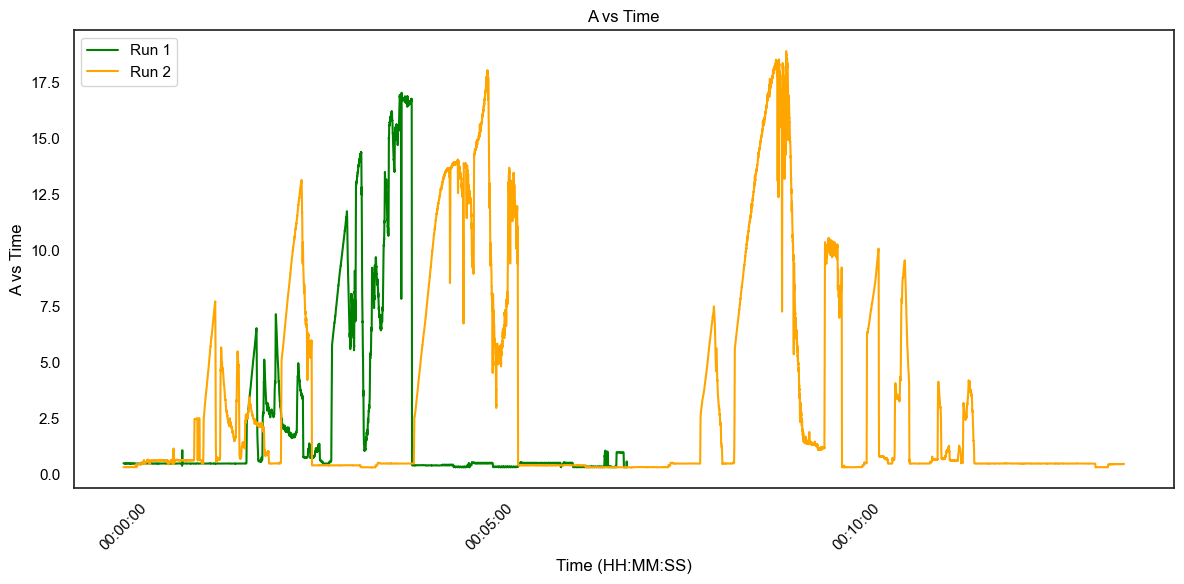

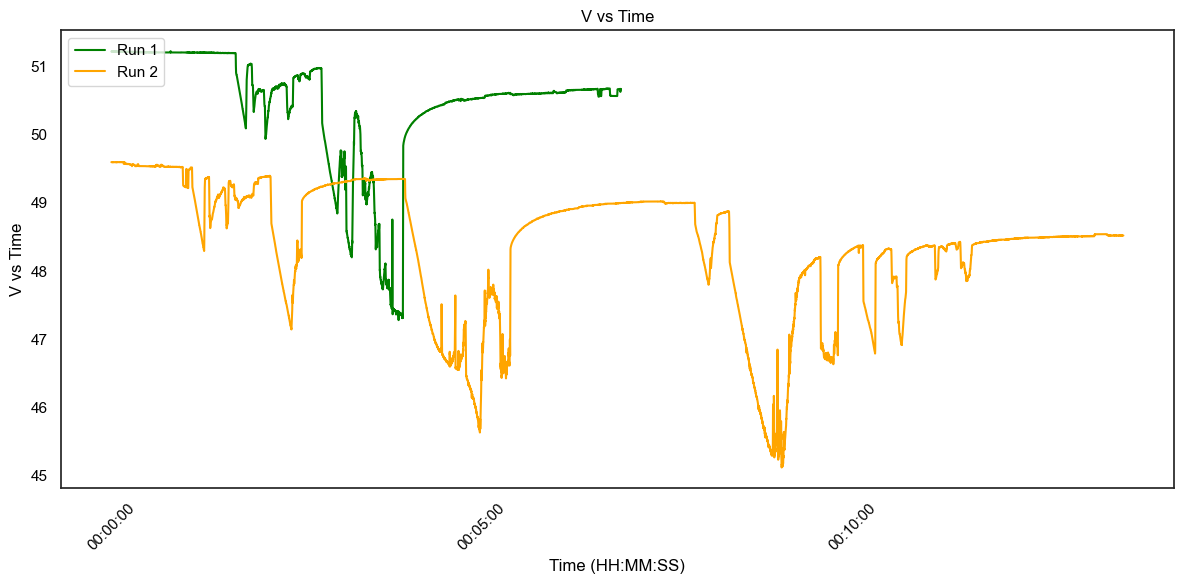

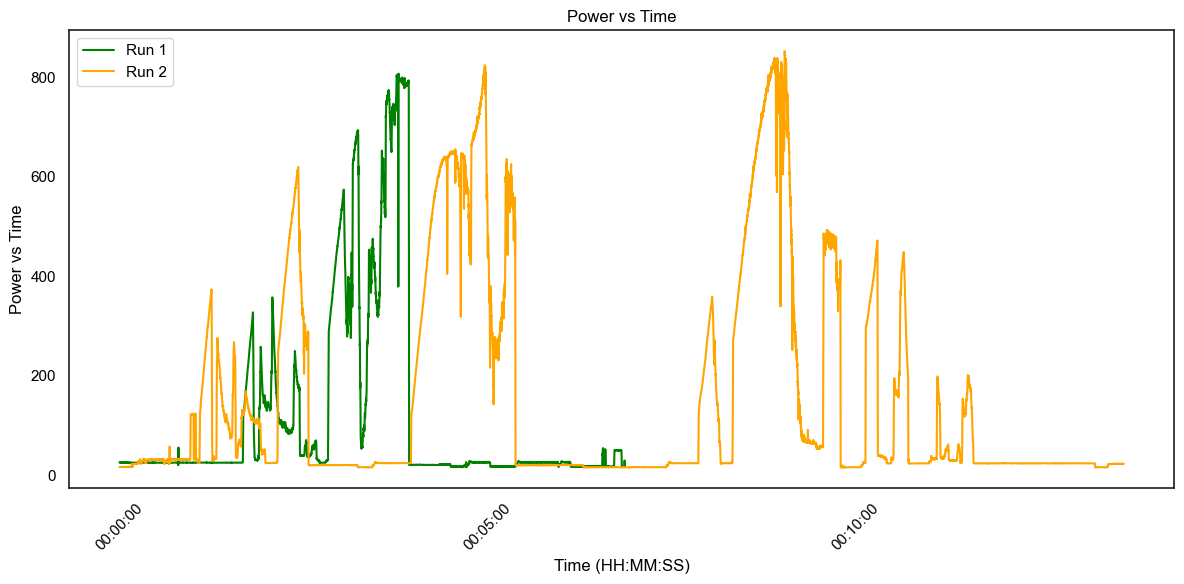

In [2]:
#Overlay power consumption of a second run

sns.set(style='white')  # light background
date = "250817"
time = "131122"
data_folder = f'./{date}/'
file = f'{date}-{time}.csv'
path = os.path.join(data_folder, file)
delimiter = ','
skiprows = 27
distance = 2.4 #Distance in km, used for efficiency calculation
Ticks = False  # Set to False if did not correct ticks
start_throttle = 0.1  # Minimum throttle to start plotting
throttle_start_flag = False
plot_outliers = False  # Set to False to not plot outliers
# Load and clean data
# def clean_cell(cell):
#     # Keep only alphanumeric and spaces
#     return float(re.sub(r'[^a-zA-Z0-9]', '', str(cell)))
# def last_digits(cell, n=5):
#     match = re.search(r'(\d{%d})\D*$' % n, str(cell))
#     return match.group(1) if match else ''
#data_2 = pd.read_csv(path, converters={'Ticks': lambda x: last_digits(x, 5)})
#data_2['Tick'] = (data_2['Tick'].apply(clean_cell))
data_2 = pd.read_csv(path, delimiter = delimiter, skiprows = skiprows)
data_2.columns = data_2.columns.str.strip()

# Remove rows before the first throttle > start_throttle
if throttle_start_flag:
    start_throttle_index = data_2[data_2['Throttle'] >= start_throttle].index.min()
    data_2 = data_2.iloc[start_throttle_index:]

# Convert Tick to time
if Ticks:
    data_2['Tick'] = data_2['Tick'].astype(int)  # Ensure Tick is int
    data_2['Time'] = pd.to_timedelta(data_2['Tick'], unit='ms')
    data_2['TimePlot'] = pd.Timestamp("2023-01-01") + data_2['Time']
else:
    data_2['TimePlot'] = range(len(data_2))

# Convert NO to milliseconds
if 'NO.' in data_2.columns:
    data_2['milliseconds'] = data_2['NO.'] * 20

#Convert milliseconds to time
if 'milliseconds' in data_2.columns:
    data_2['Time'] = pd.to_timedelta(data_2['milliseconds'], unit='ms')
    data_2['TimePlot'] = pd.Timestamp("2023-01-01") + data_2['Time']

# Check for missing values
print("\nMissing values per column:")
print(data_2.isnull().sum())

#Convert to actual numbers
data_2['A'] = data_2['A'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)
data_2['V'] = data_2['V'].str.replace('+ ', '', regex=False).str.replace('- ', '', regex=False).astype(float)

#Add power calculation
if 'A' in data_2.columns and 'V' in data_2.columns:
    data_2['Power'] = (data_2['A']) * (data_2['V'])

#Add total energy calculation
if 'Power' in data_2.columns:
    energy_joules = np.trapz(data_2['Power'], x = data_2['milliseconds'] / 1e3)
    energy_kWh = energy_joules / 3600000  # Convert from J to kWh
    print(f"\nTotal energy consumed: {energy_kWh} kWh")

if distance !=1:
    #Calculate efficiency
    efficiency = distance/energy_kWh  # kWh per meter
    print(f"\nEfficiency: {efficiency:.2f} km/kWh")



# Columns to visualize
#columns_to_plot = ['Throttle', 'Speed', 'Current', 'Voltage', 'Speed1']
columns_to_plot = ['A','V','Power']
#data_2.dropna(subset=['TimePlot'] + columns_to_plot, inplace=True)

# Plot each column
for col in columns_to_plot:
    if col in data_2.columns:
        x_1 = data['TimePlot']
        y_1 = data[col]
        y_1_smooth = y_1.rolling(window=10).mean()
        x_2 = data_2['TimePlot']
        y_2 = data_2[col]
        y_2_smooth = y_2.rolling(window=10).mean()

        # Stats
        avg = y.mean()
        med = y.median()

        # Outliers (Z-score method)
        z_scores = zscore(y)
        outliers = np.abs(z_scores) > 2

        # Start plotting
        fig, ax = plt.subplots(figsize=(12, 6))

        #Use numpy arrays for plotting with only first dimension (this is weird)
    

        # Smoothed line
        ax.plot(x_1, y_1_smooth, color='green', label=f'Run 1')
        ax.plot(x_2, y_2_smooth, color='orange', label=f'Run 2')
        # Labeling and formatting
        ax.set_xlabel("Time (HH:MM:SS)", color='black')
        ax.set_ylabel(f"{col} vs Time", color='black')
        ax.set_title(f"{col} vs Time", color='black')
        ax.tick_params(axis='x', colors='black', rotation=45)
        ax.tick_params(axis='y', colors='black')

        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

        # Legend in black
        legend = ax.legend(loc='upper left')
        for text in legend.get_texts():
            text.set_color('black')

        plt.tight_layout()
        plt.show()
    else:
        print(f"Column '{col}' not found in dataset.")